In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv("laei2019_model_data.csv")

print(df.shape)
print(df.head())
print(df.isna().sum().sort_values(ascending=False).head())

(66962, 25)
                   TOID               Borough  NOx_total_2019  \
0  osgb4000000030337102               Bromley        0.197933   
1  osgb4000000030221346                 Brent        0.294039   
2  osgb4000000030365896  Barking and Dagenham        0.237709   
3  osgb4000000030409722            Hillingdon        0.044987   
4  osgb4000000030132840              Hounslow        0.731842   

   AADT Motorcycle  AADT Taxi  AADT Petrol Car  AADT Diesel Car  \
0            242.0      118.0           6396.0           4420.0   
1            405.0      148.0          10718.0           7407.0   
2            364.0      174.0           9468.0           6544.0   
3            137.0       40.0           3978.0           2749.0   
4            416.0      412.0          10928.0           7552.0   

   AADT Electric Car  AADT Petrol PHV  AADT Diesel PHV  ...  \
0               38.0            126.0            104.0  ...   
1               63.0            318.0            262.0  ...   
2    

In [9]:
X = df.drop(columns=["TOID", "Borough", "NOx_total_2019"])

y = df["NOx_total_2019"]

print(X.shape)
print(y.shape)

(66962, 22)
(66962,)


In [10]:
categorical_features = ["Road Classification"]

numeric_features = [col for col in X.columns if col not in categorical_features]

print("Numeric features:")
print(len(numeric_features))

print("\nCategorical features:")
print(categorical_features)

Numeric features:
21

Categorical features:
['Road Classification']


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("Training rows:")
print(len(X_train))

print("\nTesting rows:")
print(len(X_test))

Training rows:
53569

Testing rows:
13393


In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

In [13]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

In [14]:
from sklearn.dummy import DummyRegressor

dummy_model = Pipeline([("preprocessor", preprocessor), ("model", DummyRegressor(strategy="mean"))])

dummy_model.fit(X_train, y_train)

dummy_predictions = dummy_model.predict(X_test)

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

dummy_mae = mean_absolute_error(y_test, dummy_predictions)
dummy_rmse = np.sqrt(mean_squared_error(y_test, dummy_predictions))
dummy_r2 = r2_score(y_test, dummy_predictions)

print("Mean Baseline")
print("MAE:", dummy_mae)
print("RMSE:", dummy_rmse)
print("R²:", dummy_r2)

Mean Baseline
MAE: 0.18669178758667473
RMSE: 0.4446942032741145
R²: -0.001274191355049581


In [16]:
from sklearn.linear_model import LinearRegression

linear_model = Pipeline([("preprocessor", preprocessor), ("model", LinearRegression())])

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

In [17]:
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression")
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R²:", linear_r2)

Linear Regression
MAE: 0.1288187511308011
RMSE: 0.28828437630691645
R²: 0.579203326571746


In [18]:
from sklearn.linear_model import Ridge

ridge_model = Pipeline([("preprocessor", preprocessor), ("model", Ridge(alpha=1.0))])

ridge_model.fit(X_train, y_train)

ridge_predictions = ridge_model.predict(X_test)

In [19]:
ridge_mae = mean_absolute_error(y_test, ridge_predictions)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_predictions))
ridge_r2 = r2_score(y_test, ridge_predictions)

print("Ridge Regression")
print("MAE:", ridge_mae)
print("RMSE:", ridge_rmse)
print("R²:", ridge_r2)

Ridge Regression
MAE: 0.12879866256914643
RMSE: 0.288271098447286
R²: 0.5792420879542692


In [20]:
results = pd.DataFrame({
    "Model": ["Mean Baseline", "Linear Regression", "Ridge Regression"],
    "MAE": [dummy_mae, linear_mae, ridge_mae],
    "RMSE": [dummy_rmse, linear_rmse, ridge_rmse],
    "R2": [dummy_r2, linear_r2, ridge_r2]
})

print(results)

               Model       MAE      RMSE        R2
0      Mean Baseline  0.186692  0.444694 -0.001274
1  Linear Regression  0.128819  0.288284  0.579203
2   Ridge Regression  0.128799  0.288271  0.579242


In [21]:
linear_train_predictions = linear_model.predict(X_train)
ridge_train_predictions = ridge_model.predict(X_train)

linear_train_r2 = r2_score(y_train, linear_train_predictions)
ridge_train_r2 = r2_score(y_train, ridge_train_predictions)

print("Linear Regression")
print("Train R²:", linear_train_r2)
print("Test R²:", linear_r2)

print("\nRidge Regression")
print("Train R²:", ridge_train_r2)
print("Test R²:", ridge_r2)

Linear Regression
Train R²: 0.7528567972971609
Test R²: 0.579203326571746

Ridge Regression
Train R²: 0.7528487347011221
Test R²: 0.5792420879542692


In [22]:
print("Negative Linear Regression predictions:")
print((linear_predictions < 0).sum())

print("\nNegative Ridge Regression predictions:")
print((ridge_predictions < 0).sum())

Negative Linear Regression predictions:
4600

Negative Ridge Regression predictions:
4605


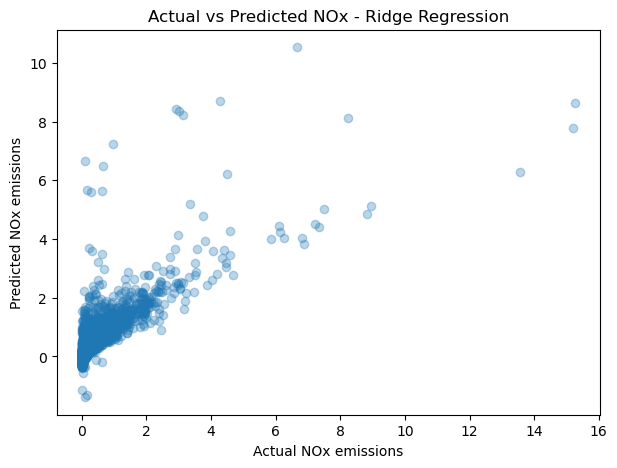

In [23]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, ridge_predictions, alpha=0.3)
plt.xlabel("Actual NOx emissions")
plt.ylabel("Predicted NOx emissions")
plt.title("Actual vs Predicted NOx - Ridge Regression")
plt.show()

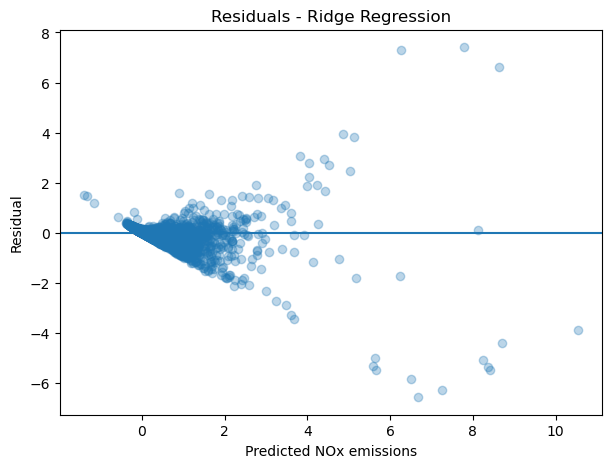

In [24]:
ridge_residuals = y_test - ridge_predictions

plt.figure(figsize=(7, 5))
plt.scatter(ridge_predictions, ridge_residuals, alpha=0.3)
plt.axhline(0)
plt.xlabel("Predicted NOx emissions")
plt.ylabel("Residual")
plt.title("Residuals - Ridge Regression")
plt.show()

In [25]:
error_df = pd.DataFrame({
    "Actual_NOx": y_test,
    "Predicted_NOx": ridge_predictions
})

error_df["Absolute_Error"] = abs(error_df["Actual_NOx"] - error_df["Predicted_NOx"])

print(error_df.sort_values("Absolute_Error", ascending=False).head(10))

       Actual_NOx  Predicted_NOx  Absolute_Error
40038   15.186764       7.775600        7.411164
39826   13.553714       6.269557        7.284157
39841   15.259477       8.642570        6.616906
40107    0.094088       6.666864        6.572776
40126    0.976825       7.250713        6.273888
40103    0.655677       6.497996        5.842319
40109    2.917997       8.415906        5.497910
40183    0.173250       5.669132        5.495882
40141    3.020769       8.369046        5.348277
36513    0.280597       5.595753        5.315157


In [26]:
results.to_csv("regression_results.csv", index=False)

print("Regression results saved successfully.")

Regression results saved successfully.


In [27]:
plt.savefig("ridge_actual_vs_predicted.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>